In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.seasonal import STL

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [2]:
data = pd.read_csv("../../Downloads/iex_dam_feb_mar_2026.csv")

In [3]:
# conforming type
data["period_start"] = pd.to_datetime(data["period_start"])
data["period_enum"] = data["period_start"].dt.hour * 4 + data["period_start"].dt.minute // 15 + 1
data["weekday_enum"] = data["period_start"].dt.weekday + 1

In [4]:
data["pb_lag1d"] = data["purchase_bid"].shift(96)
data["sb_lag1d"] = data["sell_bid"].shift(96)
data["pb_lag2d"] = data["purchase_bid"].shift(192)
data["sb_lag2d"] = data["sell_bid"].shift(192)

data['target_diff'] = data['purchase_bid']

data_clean = data.dropna()

print(f"New feature count: {len(data_clean.columns)}")
data_clean.head()

New feature count: 16


,period_start,period,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume,period_enum,weekday_enum,pb_lag1d,sb_lag1d,pb_lag2d,sb_lag2d,ucv,ucv_lag1d,target_diff
192,2026-02-03 00:00:00,00:00 - 00:15,11816.4,30030.2,7074.50,2440.64,7074.50,1,2,12380.9,29543.7,11446.6,30678.9,4741.90,5155.00,11816.4
193,2026-02-03 00:15:00,00:15 - 00:30,12001.8,32385.0,7265.10,2440.58,7265.10,2,2,13084.5,31204.4,12066.8,32484.0,4736.70,5881.35,12001.8
194,2026-02-03 00:30:00,00:30 - 00:45,13033.6,33866.9,7615.70,2500.15,7615.70,3,2,13621.6,32825.1,12510.9,34476.2,5417.90,6311.57,13033.6
195,2026-02-03 00:45:00,00:45 - 01:00,13322.1,35093.5,7674.00,2510.67,7674.00,4,2,13675.3,34558.3,12502.6,36013.3,5648.10,5865.91,13322.1
196,2026-02-03 01:00:00,01:00 - 01:15,13459.3,35489.0,7996.69,2500.81,7996.69,5,2,13720.1,35119.1,12423.8,36515.8,5462.61,5817.89,13459.3


## LightGBM

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[770]	train's rmse: 1243.57	valid's rmse: 2385.91

--- Model Performance ---
MAE: 2069.90
RMSE: 5692588.74


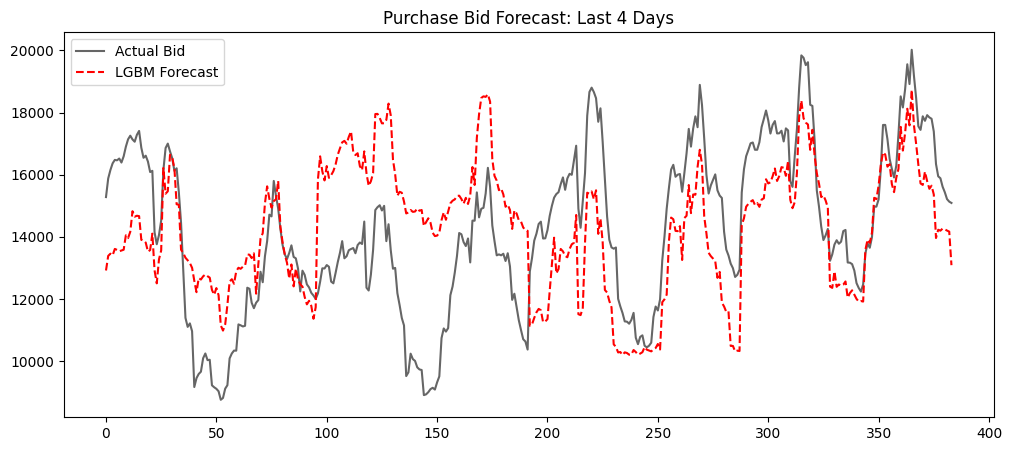

In [129]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Define Features and Target
# Using the lags you created in cell [5] plus your enums
features = [
    'period_enum', 'weekday_enum', 
    'pb_lag1d', 'pb_lag2d'
    # 'pb_lag1d_plus1', 'pb_lag1d_plus2', 'pb_lag1d_minus1', 'pb_lag1d_minus2',
    # 'sb_lag1d',
    # 'sb_lag1d_plus1', 'sb_lag1d_plus2', 'sb_lag1d_minus1', 'sb_lag1d_minus2'
]
target = 'purchase_bid'

X = data_clean[features]
y = data_clean[target]

# 2. Time-Series Split (Don't use random_split for time data!)
# We'll take the last 4 days (96 * 4) as our test set
test_size = 96*4 
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# 3. Create LightGBM Datasets
# Explicitly telling LightGBM which columns are categorical
cat_features = ['period_enum']#, 'weekday_enum']
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=cat_features)

# 4. Set Parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.005,
    'num_leaves': 64,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1
}

# 5. Train the Model
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'valid'],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 6. Predict and Evaluate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print(f"\n--- Model Performance ---")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# 7. Quick Visualization
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Bid', color='black', alpha=0.6)
plt.plot(y_pred, label='LGBM Forecast', color='red', linestyle='--')
plt.title('Purchase Bid Forecast: Last 4 Days')
plt.legend()
plt.show()

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_92223/2794048663.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


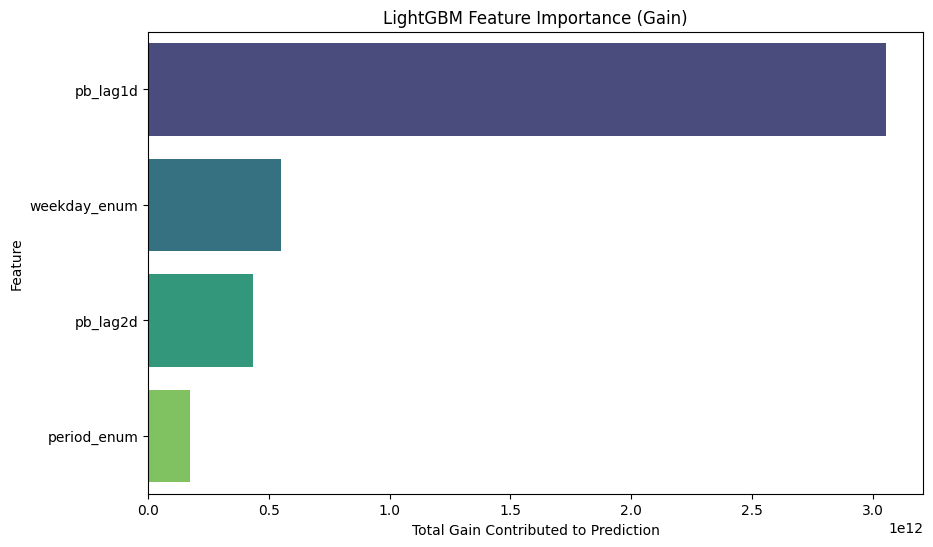

        Feature    Importance
2      pb_lag1d  3.055373e+12
1  weekday_enum  5.504715e+11
3      pb_lag2d  4.336187e+11
0   period_enum  1.756626e+11


In [130]:
import pandas as pd
import seaborn as sns

# 1. Get feature importance (using 'gain' to see contribution to error reduction)
importance = model.feature_importance(importance_type='gain')
feature_names = model.feature_name()

# 2. Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('LightGBM Feature Importance (Gain)')
plt.xlabel('Total Gain Contributed to Prediction')
plt.show()

# Optional: Print the raw values
print(feature_importance_df)

## LSTM

In [85]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

# 1. Define your specific features
features = [
    'period_enum', 'weekday_enum', 
    'pb_lag1d', 'pb_lag2d', #'pb_lag1d_plus1', 'pb_lag1d_plus2', 'pb_lag1d_minus1', 'pb_lag1d_minus2',
    # 'sb_lag1d', 'sb_lag2d' #'sb_lag1d_plus1', 'sb_lag1d_plus2', 'sb_lag1d_minus1', 'sb_lag1d_minus2'
]
target = 'purchase_bid'

# 2. Scaling (CRITICAL for LSTMs)
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(data_clean[features])
y_scaled = scaler_y.fit_transform(data_clean[[target]])

# 3. Time-Series Split
test_size = 96 * 4
X_train_raw, X_test_raw = X_scaled[:-test_size], X_scaled[-test_size:]
y_train, y_test = y_scaled[:-test_size], y_scaled[-test_size:]

# 4. Reshape to 3D: [Samples, Time Steps, Features]
# Here we treat each row as 1 time step with 12 features
X_train = X_train_raw.reshape((X_train_raw.shape[0], 1, X_train_raw.shape[1]))
X_test = X_test_raw.reshape((X_test_raw.shape[0], 1, X_test_raw.shape[1]))

# 5. Build the LSTM Model
model = Sequential([
    # Input shape is (Time Steps, Features)
    LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dense(1) # Predicting the single purchase_bid value
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 6. Train
history = model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1
)

# 7. Predict and Inverse Scale
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

# 8. Evaluate
mae = mean_absolute_error(y_test_actual, y_pred)
print(f"LSTM MAE: {mae:.2f}")

Task was destroyed but it is pending!
task: <Task pending name='Task-950' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-951' coro=<Kernel.shell_main() running at /Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/pandas/core/flags.py:53: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  self._obj = weakref.ref(obj)
Task was destroyed but it is pending!
task: <Task pending name='Task-951' coro=<Kernel.shell_main() running at /Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[T

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0420 - mae: 0.1576 - val_loss: 0.0092 - val_mae: 0.0773
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - loss: 0.0087 - mae: 0.0703 - val_loss: 0.0059 - val_mae: 0.0648
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - loss: 0.0075 - mae: 0.0632 - val_loss: 0.0050 - val_mae: 0.0599
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - loss: 0.0070 - mae: 0.0611 - val_loss: 0.0046 - val_mae: 0.0574
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - loss: 0.0069 - mae: 0.0609 - val_loss: 0.0043 - val_mae: 0.0560
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - loss: 0.0067 - mae: 0.0598 - val_loss: 0.0047 - val_mae: 0.0559
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - loss: 0.0069 - mae: 0.0609 - val_loss: 0.0041 - val_mae: 0.0541
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 0.0065 - mae: 0.0593 - val_loss: 0.0042 - val_mae: 0.0539
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s

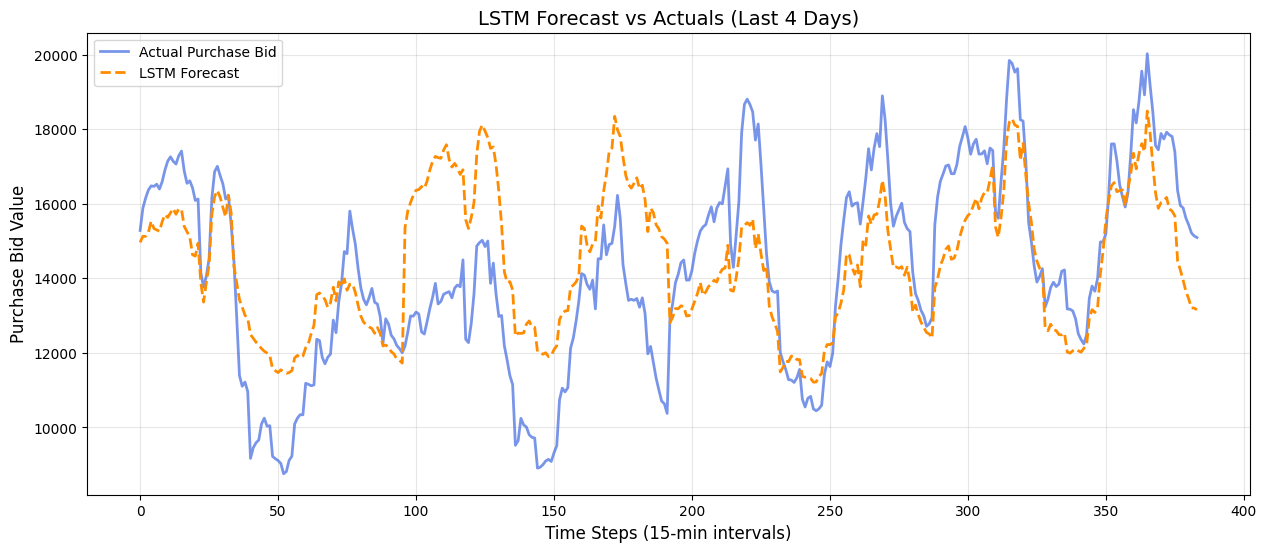

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Plotting the actual values
plt.plot(y_test_actual, label='Actual Purchase Bid', color='royalblue', linewidth=2, alpha=0.7)

# Plotting the LSTM predictions
plt.plot(y_pred, label='LSTM Forecast', color='darkorange', linewidth=2, linestyle='--')

plt.title(f'LSTM Forecast vs Actuals (Last {test_size//96} Days)', fontsize=14)
plt.xlabel('Time Steps (15-min intervals)', fontsize=12)
plt.ylabel('Purchase Bid Value', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Optional: Zoom in on the last 2 days for better clarity
# plt.xlim(192, 384) 

plt.show()

Calculating permutation importance (this may take a moment)...


/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_92223/1691371537.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


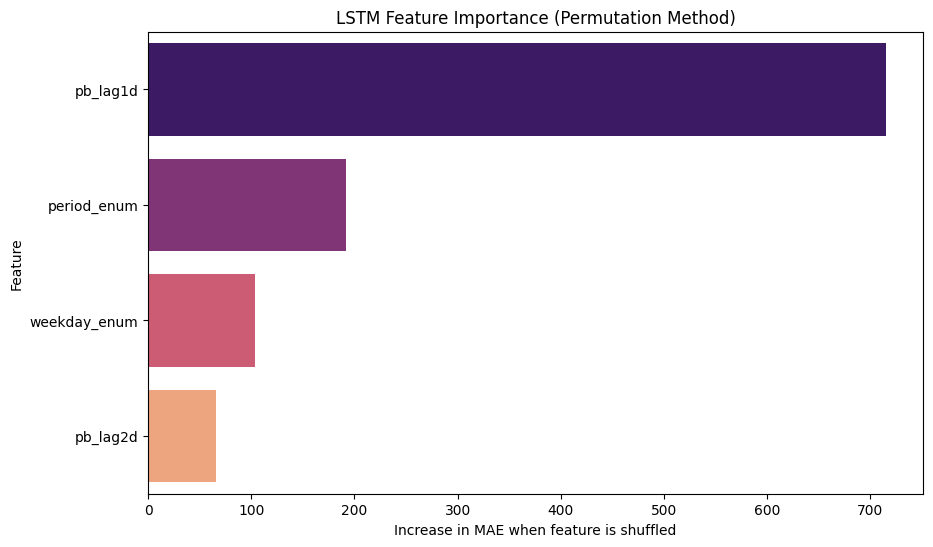

        Feature  Importance
2      pb_lag1d  715.328024
0   period_enum  191.786532
1  weekday_enum  103.258923
3      pb_lag2d   66.094964


In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate baseline MAE (already calculated as 'mae' in your LSTM cell)
baseline_mae = mae
feat_importance = []

print("Calculating permutation importance (this may take a moment)...")

for i, feat in enumerate(features):
    # Create a copy of the test set
    X_test_permuted = X_test.copy()
    
    # Shuffle only the values of the current feature across the test set
    # Since shape is (samples, 1, features), we shuffle index [:, 0, i]
    np.random.shuffle(X_test_permuted[:, 0, i])
    
    # Predict with the 'broken' feature
    y_pred_permuted_scaled = model.predict(X_test_permuted, verbose=0)
    y_pred_permuted = scaler_y.inverse_transform(y_pred_permuted_scaled)
    
    # Calculate new MAE
    permuted_mae = mean_absolute_error(y_test_actual, y_pred_permuted)
    
    # Importance is the increase in error
    importance = permuted_mae - baseline_mae
    feat_importance.append({'Feature': feat, 'Importance': importance})

# 2. Convert to DataFrame and sort
importance_df = pd.DataFrame(feat_importance).sort_values(by='Importance', ascending=False)

# 3. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('LSTM Feature Importance (Permutation Method)')
plt.xlabel('Increase in MAE when feature is shuffled')
plt.show()

print(importance_df)

In [108]:
test_days = 7

# Create a date column (without time) to group by day
data_clean['date'] = data_clean['period_start'].dt.date

# Pivot: Rows = Dates, Columns = The 96 periods
df_daily = data_clean.pivot(index='date', columns='period_enum', values='purchase_bid')
df_daily = df_daily.dropna() # Ensure we only have full 96-period days

# Scale the entire 96-column matrix
scaler = MinMaxScaler()
df_daily_scaled = scaler.fit_transform(df_daily)

train_daily_scaled = df_daily_scaled[:-test_days]
test_daily_actuals = df_daily_scaled[-test_days:]

# Create X (Day N) and y (Day N+1)
X_train_days = train_daily_scaled[:-1] 
y_train_days = train_daily_scaled[1:]

# Reshape for LSTM: [Samples, Time Steps, Features]
# Features = 96 (the whole day)
X_train_days = X_train_days.reshape((X_train_days.shape[0], 1, 96))
y_train_days = y_train_days.reshape((y_train_days.shape[0], 96))

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_92223/338106326.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['date'] = data_clean['period_start'].dt.date


In [109]:
print(f"Training on {X_train_days.shape[0]} days.")
print(f"Holding out {test_days} days for testing.")

Training on 43 days.
Holding out 7 days for testing.


In [107]:
X_days.shape, y_days.shape

((50, 1, 96), (50, 96))

In [110]:
from tensorflow.keras.layers import RepeatVector, TimeDistributed

model_vector = Sequential([
    # Input is the 96 values of yesterday
    LSTM(128, activation='relu', input_shape=(1, 96), return_sequences=True),
    LSTM(64, activation='relu'),
    # Output is the 96 values of tomorrow
    Dense(96) 
])

model_vector.compile(optimizer='adam', loss='mse')
model_vector.fit(X_train_days, y_train_days, epochs=100, batch_size=16, verbose=1)

Epoch 1/100


/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3108
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3023 
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2898 
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2723 
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2441 
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2097 
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1745 
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1621 
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1347
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1122 
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0966 
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0826 
Epoch 13/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0720 
Epoch 14/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0648 
Epoch 15/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0559 
Epoch 16/100
3/3 ━━━━━━━━━━━━━━━

In [111]:
# Start recursion using the day IMMEDIATELY PRECEDING your test set
current_input = train_daily_scaled[-1:].reshape((1, 1, 96))

test_predictions = []

for day in range(test_days):
    # Predict next day
    next_day_pred = model_vector.predict(current_input, verbose=0)
    test_predictions.append(next_day_pred.flatten())
    
    # Feed prediction back in for the next day's forecast
    current_input = next_day_pred.reshape((1, 1, 96))

# Convert list to array for inverse scaling
test_pred_matrix = np.array(test_predictions)
final_7day_test_forecast = scaler.inverse_transform(test_pred_matrix).flatten()

# Get actual values for the same 7 days for comparison
actual_7day_values = scaler.inverse_transform(test_daily_actuals).flatten()

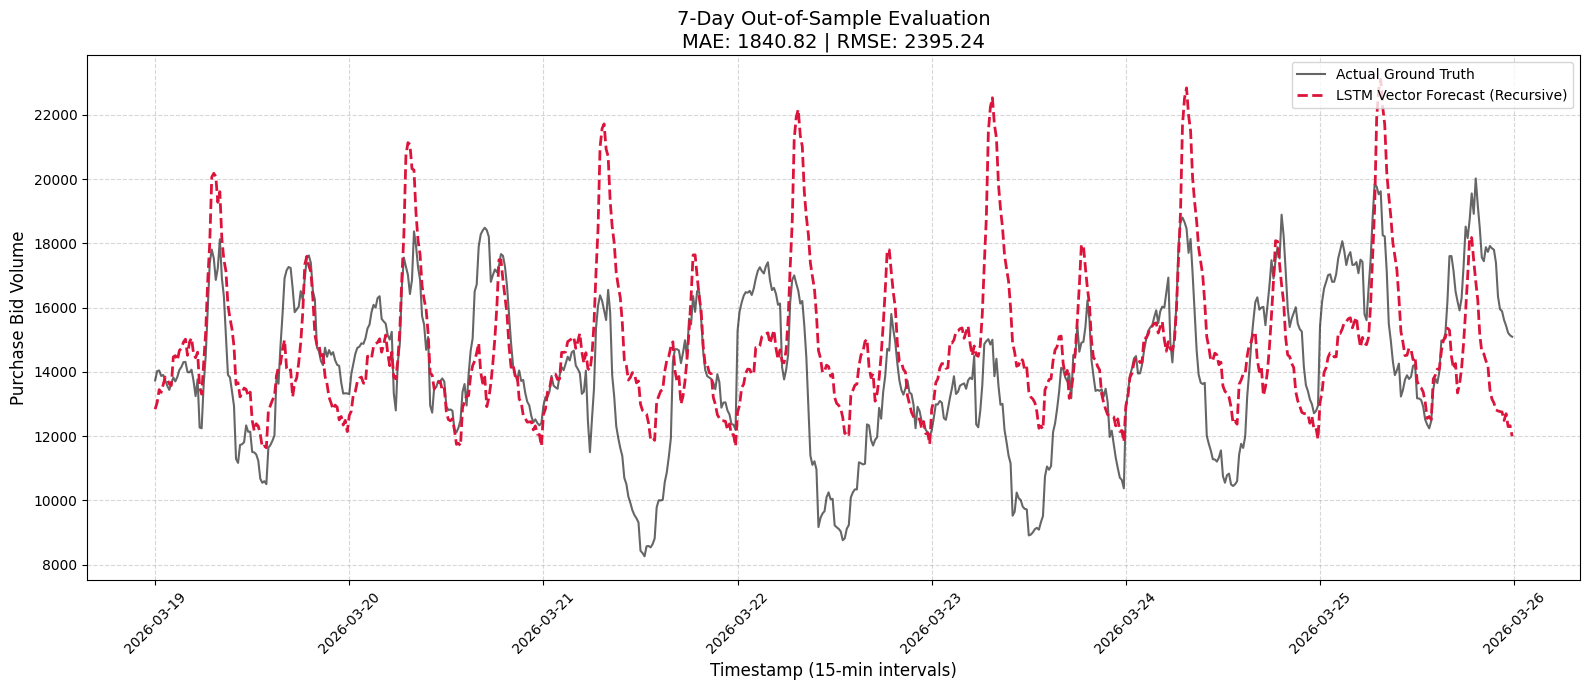

Day 1 MAE: 1167.81
Day 2 MAE: 1145.63
Day 3 MAE: 1971.95
Day 4 MAE: 2497.86
Day 5 MAE: 2400.97
Day 6 MAE: 1592.70
Day 7 MAE: 2108.83


In [112]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Get the timestamps for the test period (last 7 days)
test_size = 96 * 7
test_timestamps = data_clean['period_start'].iloc[-test_size:]

# 2. Calculate Evaluation Metrics
mae_7d = mean_absolute_error(actual_7day_values, final_7day_test_forecast)
rmse_7d = np.sqrt(mean_squared_error(actual_7day_values, final_7day_test_forecast))

# 3. Create the Visualization
plt.figure(figsize=(16, 7))

# Plot the Actual Ground Truth
plt.plot(test_timestamps, actual_7day_values, label='Actual Ground Truth', color='black', alpha=0.6, linewidth=1.5)

# Plot the Model's 7-Day Recursive Forecast
plt.plot(test_timestamps, final_7day_test_forecast, label='LSTM Vector Forecast (Recursive)', 
         color='crimson', linestyle='--', linewidth=2)

# Styling and Labels
plt.title(f'7-Day Out-of-Sample Evaluation\nMAE: {mae_7d:.2f} | RMSE: {rmse_7d:.2f}', fontsize=14)
plt.xlabel('Timestamp (15-min intervals)', fontsize=12)
plt.ylabel('Purchase Bid Volume', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 4. Print individual day MAEs to see error growth
for d in range(7):
    day_mae = mean_absolute_error(actual_7day_values[d*96:(d+1)*96], 
                                 final_7day_test_forecast[d*96:(d+1)*96])
    print(f"Day {d+1} MAE: {day_mae:.2f}")

In [100]:
# Start with the very last day in your training set (March 31st)
last_day_vector = df_daily_scaled[-1:].reshape((1, 1, 96))

all_forecasts = []
current_input = last_day_vector

for day in range(7):
    # Predict the entire next day (96 blocks) in one go
    next_day_scaled = model_vector.predict(current_input, verbose=0)
    
    # Store result
    all_forecasts.append(next_day_scaled.flatten())
    
    # Update input: Today's prediction becomes tomorrow's input
    current_input = next_day_scaled.reshape((1, 1, 96))

# Flatten and Inverse Scale
forecast_flat = np.array(all_forecasts).flatten().reshape(-1, 1)
# Create a dummy matrix to inverse scale (since scaler expects 96 columns)
dummy_matrix = np.zeros((len(all_forecasts), 96))
for i in range(len(all_forecasts)):
    dummy_matrix[i] = all_forecasts[i]

final_7day_forecast = scaler.inverse_transform(dummy_matrix).flatten()

In [101]:
final_7day_forecast

array([14550.59644962, 15642.95401421, 16478.12095876, 15465.77278064,
       16980.22180011, 16234.73115466, 16390.18454975, 16179.60740035,
       16419.77667813, 16455.88824449, 16422.70989112, 17396.80255958,
       17317.8841085 , 17194.80673676, 17942.96669893, 17331.7095108 ,
       16970.16000865, 17349.75812292, 17539.32682403, 17403.11521732,
       17260.79821118, 17373.28944679, 15680.95511616, 15291.71234899,
       15887.5056195 , 17088.83097092, 18071.38098152, 19698.42832699,
       22281.65537481, 21051.42798607, 20661.91826224, 20930.85077187,
       20087.45605284, 19273.94352113, 18358.25072293, 17374.47144887,
       16617.98893985, 16825.51868502, 16036.48391495, 15764.93373401,
       14292.02846899, 15097.20210565, 14199.25134782, 13961.43169752,
       15291.49692093, 14173.34076868, 14665.66214747, 14711.73015562,
       14030.69093155, 14145.83992538, 14352.4309494 , 14459.30151474,
       13787.99406991, 13293.93768567, 12784.49466249, 13235.51873119,
      

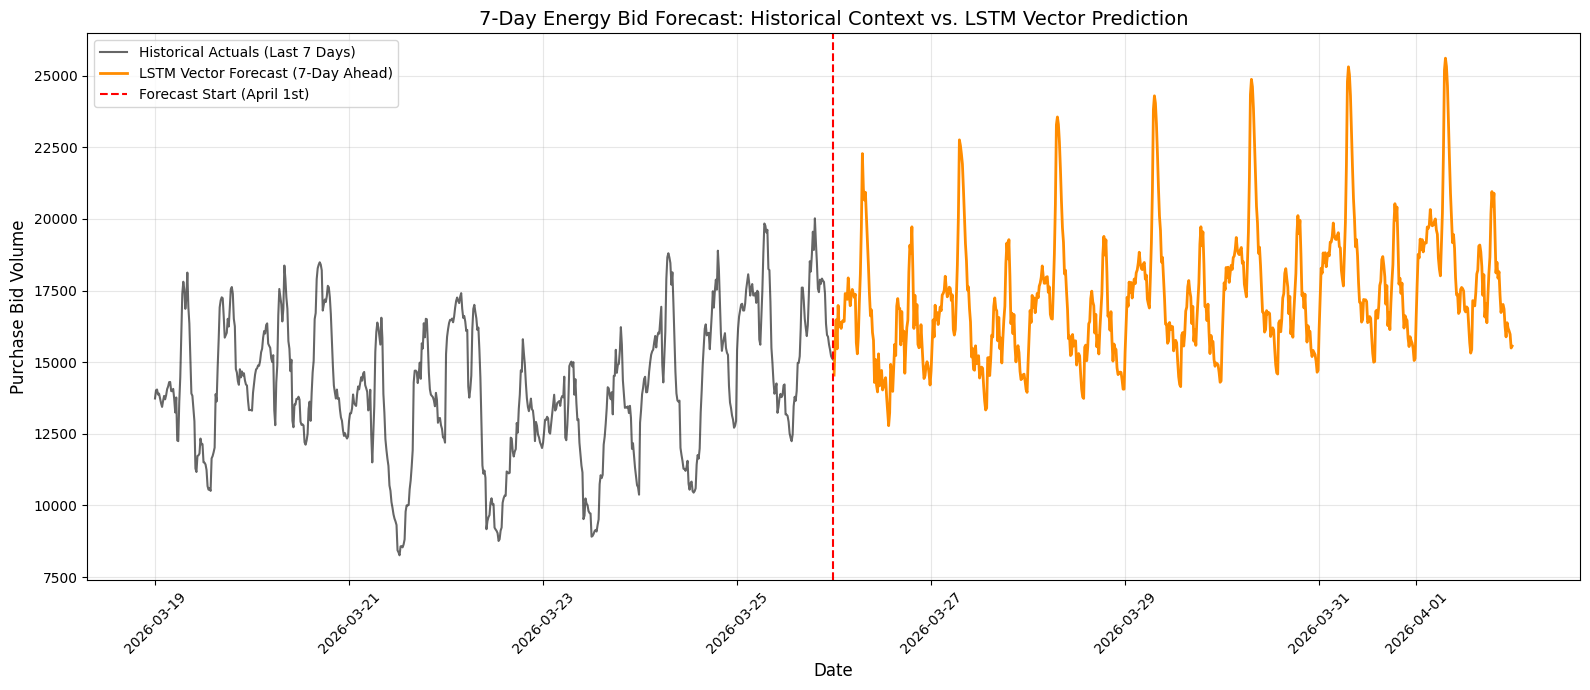

In [103]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Define the timeframe for history (last 7 days)
history_size = 96 * 7 

# 2. Extract historical data for the plot
history_y = data_clean['purchase_bid'].tail(history_size)
history_x = data_clean['period_start'].tail(history_size)

# 3. Create the forecast timeline starting from the last date in data_clean
last_timestamp = data_clean['period_start'].iloc[-1]
forecast_x = pd.date_range(start=last_timestamp + pd.Timedelta(minutes=15), 
                           periods=len(final_7day_forecast), freq='15min')

# 4. Plotting
plt.figure(figsize=(16, 7))

# Plot historical actuals
plt.plot(history_x, history_y, label='Historical Actuals (Last 7 Days)', color='black', alpha=0.6)

# Plot the 7-day Vector LSTM Forecast
plt.plot(forecast_x, final_7day_forecast, label='LSTM Vector Forecast (7-Day Ahead)', 
         color='darkorange', linewidth=2, linestyle='-')

# Add a vertical line to mark the start of the forecast
plt.axvline(x=last_timestamp, color='red', linestyle='--', label='Forecast Start (April 1st)')

plt.title('7-Day Energy Bid Forecast: Historical Context vs. LSTM Vector Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Purchase Bid Volume', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [113]:
# 1. Create the 7-day lag (essential for weekly patterns)
data_clean['pb_lag7d'] = data['purchase_bid'].shift(96 * 7)
data_clean = data_clean.dropna()

# 2. Pivot all features into daily vectors
# We create a dictionary of "daily matrices"
feature_cols = ['purchase_bid', 'pb_lag1d', 'pb_lag2d', 'pb_lag7d', 'period_enum', 'weekday_enum']
daily_matrices = {}

for col in feature_cols:
    daily_matrices[col] = data_clean.pivot(index='date', columns='period_enum', values=col).dropna()

# Ensure all matrices have the same dates (intersection)
common_dates = daily_matrices['purchase_bid'].index
for col in feature_cols:
    daily_matrices[col] = daily_matrices[col].loc[common_dates]

# 3. Scale each feature channel individually
scalers = {col: MinMaxScaler() for col in feature_cols}
scaled_matrices = {col: scalers[col].fit_transform(daily_matrices[col]) for col in feature_cols}

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_92223/3634135237.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['pb_lag7d'] = data['purchase_bid'].shift(96 * 7)


In [117]:
# Features for the model: Lag1, Lag2, Lag7, Period_Enum, Weekday_Enum
# (Note: 'purchase_bid' is our target for the NEXT day)

def create_3d_dataset(matrices, test_days=7):
    X, y = [], []
    # dates = list(matrices['purchase_bid'].index)

    num_days = matrices['purchase_bid'].shape[0]
    # We use matrices['pb_lag1d'], etc., as inputs for day D to predict matrices['purchase_bid'] for day D
    # Actually, to predict Tomorrow (D+1), we use Today's (D) features.
    
    for i in range(num_days - 1):
        # Create a 96x5 slice for the day
        day_features = np.stack([
            scaled_matrices['pb_lag1d'][i],
            scaled_matrices['pb_lag2d'][i],
            scaled_matrices['pb_lag7d'][i],
            scaled_matrices['period_enum'][i],
            scaled_matrices['weekday_enum'][i]
        ], axis=-1) # Shape: (96, 5)
        
        X.append(day_features)
        y.append(scaled_matrices['purchase_bid'][i+1]) # Target: Tomorrow's actual bids
        
    return np.array(X), np.array(y)

X_all, y_all = create_3d_dataset(scaled_matrices)

# Split for testing
X_train, X_test = X_all[:-7], X_all[-7:]
y_train, y_test = y_all[:-7], y_all[-7:]

In [118]:
from tensorflow.keras.layers import Flatten

model_multi = Sequential([
    # Input shape: (96 time steps, 5 features per step)
    LSTM(128, activation='relu', input_shape=(96, 5), return_sequences=True),
    LSTM(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(96) # Output: All 96 periods for the next day
])

model_multi.compile(optimizer='adam', loss='mse')
model_multi.fit(X_train, y_train, epochs=100, batch_size=16, verbose=1)

Epoch 1/100


/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.3282
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3139
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2880
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 114746.1562
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 627579.3125
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 119767160.0000
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2374
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2596
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2701
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2759
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2789
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2798
Epoch 13/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2791
Epoch 14/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2768
Epoch 15/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2719
Epoch 16/100


In [119]:
# Start with the last available training day features
# For a true recursive forecast, you'd need a rolling buffer of the last 7 days of predictions
current_X = X_test[0:1] # Start with the first day of the test period
all_forecasts = []

for d in range(7):
    # 1. Predict tomorrow
    next_day_pred = model_multi.predict(current_X, verbose=0)
    all_forecasts.append(next_day_pred.flatten())
    
    if d < 6:
        # 2. Update the input for the next step
        # This is complex because Lag2 tomorrow = Lag1 today, etc.
        # For simplicity in this vector approach, we update the Lag1 channel 
        # with our prediction and shift the others if you have a buffer.
        
        new_day = current_X.copy()
        # Update Lag1 channel (index 0) with the new prediction
        new_day[0, :, 0] = next_day_pred.flatten() 
        # Update Weekday channel (index 4)
        new_day[0, :, 4] = (new_day[0, :, 4] + (1/7)) % 1.0 
        
        current_X = new_day

# Inverse scale the results
final_forecast = scalers['purchase_bid'].inverse_transform(np.array(all_forecasts)).flatten()

In [120]:
final_forecast

array([14554.144 , 13866.014 , 14412.567 , 13547.946 , 13742.547 ,
       13853.733 , 14479.904 , 11907.827 , 14293.702 , 15345.702 ,
       13736.454 , 15131.44  , 13711.076 , 15758.9   , 15411.533 ,
       16148.893 , 14400.959 , 17703.053 , 13549.543 , 16344.708 ,
       16127.667 , 17305.408 , 12311.695 , 13129.86  , 13567.98  ,
       14449.993 , 17087.398 , 16494.578 , 20868.14  , 19359.826 ,
       17078.516 , 22125.26  , 17369.756 , 16856.588 , 16908.693 ,
       15937.372 , 15876.331 , 16480.828 , 17157.143 , 14700.529 ,
       12542.399 , 12006.15  , 13978.415 , 12099.49  , 12201.968 ,
       12781.506 , 11968.102 , 11441.096 , 12761.615 , 12341.444 ,
       13812.967 , 12442.208 , 11621.831 , 12550.639 , 12768.093 ,
       10558.169 , 12684.814 , 13072.639 , 12862.77  , 15588.364 ,
       13990.694 , 14748.098 , 14884.1455, 15001.2   , 15858.562 ,
       14839.4795, 13573.01  , 14428.693 , 15814.662 , 14309.224 ,
       14315.071 , 14668.086 , 15563.877 , 16212.745 , 17316.1

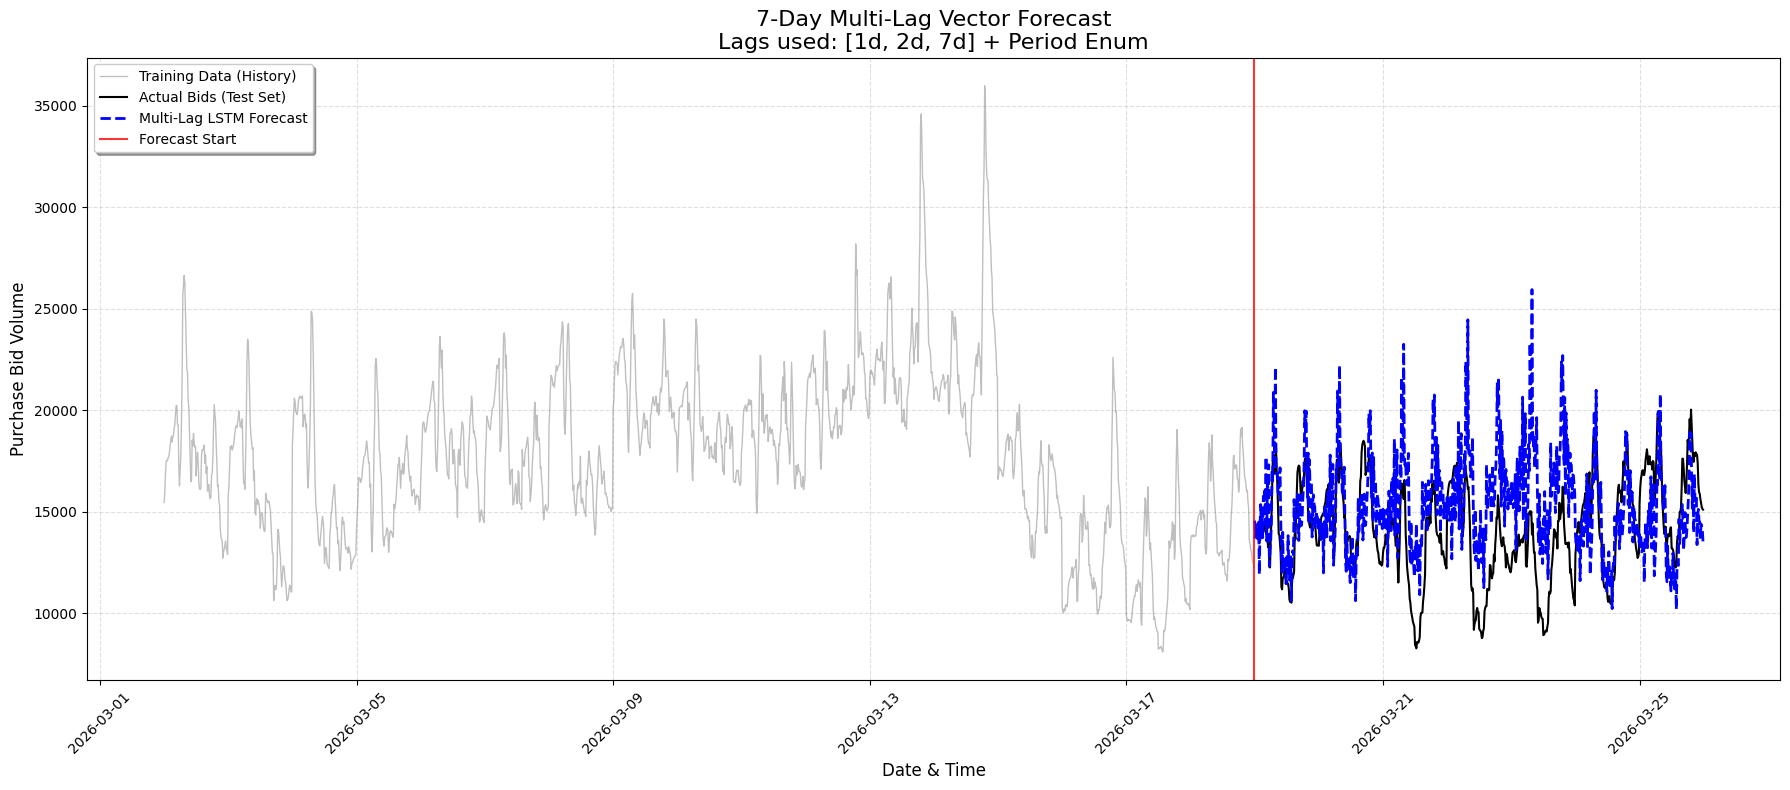

Overall 7-Day Forecast MAE: 2289.76


In [125]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Configuration
days_of_history_to_show = 17  # How many days of training data to show before the forecast
test_days = 7
steps_per_day = 96

# 2. Extract Timestamps
# The test period is the last (test_days * 96) rows
test_timestamps = data_clean['period_start'].iloc[-(test_days * steps_per_day):]

# The history period is the segment just before the test period
history_end_idx = len(data_clean) - (test_days * steps_per_day)
history_start_idx = history_end_idx - (days_of_history_to_show * steps_per_day)
history_timestamps = data_clean['period_start'].iloc[history_start_idx:history_end_idx]
history_values = data_clean['purchase_bid'].iloc[history_start_idx:history_end_idx]

# 3. Plotting
plt.figure(figsize=(18, 8))

# Plot Training History (Context)
plt.plot(history_timestamps, history_values, 
         label='Training Data (History)', color='gray', alpha=0.5, linewidth=1)

# Plot Actual Test Values
plt.plot(test_timestamps, actual_7day_values, 
         label='Actual Bids (Test Set)', color='black', linewidth=1.5)

# Plot Multi-Lag Forecast
# Ensure final_forecast is flattened if it isn't already
forecast_plot_values = final_forecast.flatten() if hasattr(final_forecast, 'flatten') else final_forecast
plt.plot(test_timestamps, forecast_plot_values, 
         label='Multi-Lag LSTM Forecast', color='blue', linestyle='--', linewidth=2)

# Add a vertical line to separate Training from Testing
plt.axvline(x=history_timestamps.iloc[-1], color='red', linestyle='-', alpha=0.8, label='Forecast Start')

# Formatting
plt.title(f'7-Day Multi-Lag Vector Forecast\nLags used: [1d, 2d, 7d] + Period Enum', fontsize=16)
plt.xlabel('Date & Time', fontsize=12)
plt.ylabel('Purchase Bid Volume', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 4. Final Accuracy Check
from sklearn.metrics import mean_absolute_error
overall_mae = mean_absolute_error(actual_7day_values, forecast_plot_values)
print(f"Overall 7-Day Forecast MAE: {overall_mae:.2f}")

Analyzing feature contributions...


/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_92223/3650030857.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


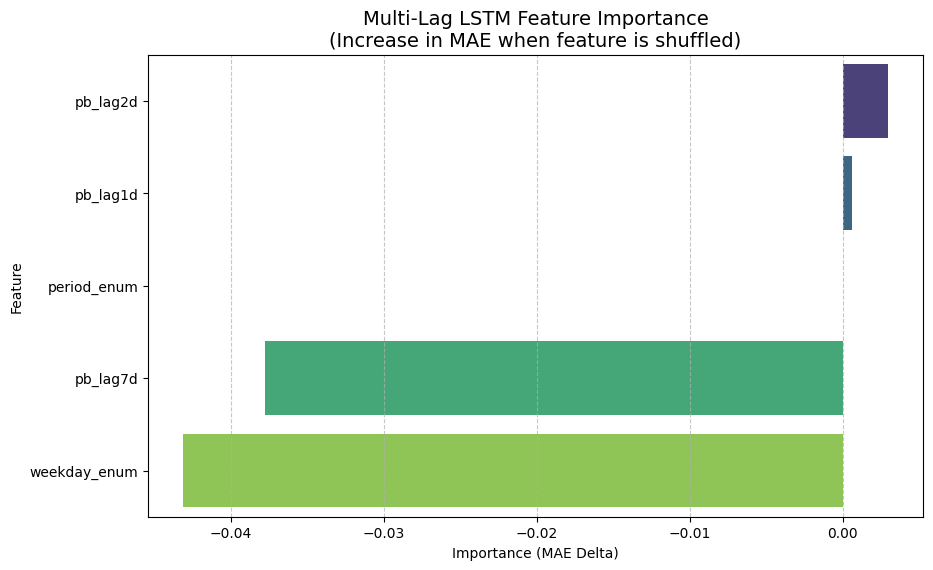

        Feature  Importance
1      pb_lag2d    0.002932
0      pb_lag1d    0.000601
3   period_enum    0.000000
2      pb_lag7d   -0.037775
4  weekday_enum   -0.043097


In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# 1. Define feature names (order must match your X_train/X_test stacking)
feature_names = ['pb_lag1d', 'pb_lag2d', 'pb_lag7d', 'period_enum', 'weekday_enum']

# 2. Calculate Baseline MAE (the error of your current model)
# Using your existing test set and predictions
y_pred_baseline = model_multi.predict(X_test, verbose=0)
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

importances = []

print("Analyzing feature contributions...")

for i, name in enumerate(feature_names):
    # Create a copy of the test set to mess with
    X_test_permuted = X_test.copy()
    
    # Shuffle the values for this specific feature channel across all days and periods
    # X_test shape is (7, 96, 5) -> we shuffle index [:, :, i]
    # We flatten, shuffle, and reshape to break the temporal relationship
    values = X_test_permuted[:, :, i].flatten()
    np.random.shuffle(values)
    X_test_permuted[:, :, i] = values.reshape(X_test_permuted.shape[0], X_test_permuted.shape[1])
    
    # Predict with the "broken" feature
    y_pred_permuted = model_multi.predict(X_test_permuted, verbose=0)
    permuted_mae = mean_absolute_error(y_test, y_pred_permuted)
    
    # Importance = how much worse the model got
    importance = permuted_mae - baseline_mae
    importances.append(importance)

# 3. Create DataFrame and Plot
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Multi-Lag LSTM Feature Importance\n(Increase in MAE when feature is shuffled)', fontsize=14)
plt.xlabel('Importance (MAE Delta)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(importance_df)